In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os 
from pathlib import Path
import xgboost as xgb
from functools import lru_cache
import optuna


In [2]:
pristine_9 = np.load("../../9_agnr_pris.csv.npy")
pristine_7 = np.load("../../7_agnr_pris.csv.npy")

In [3]:
file_path = "/Users/shardul/transmission_data/consolidated_data/size_9.npy"
file = np.load(file_path, mmap_mode="r")  

concs = np.arange(2, 60, 2)
indices = concs // 2 - 1

X = np.clip(file[indices, :10000, :150]/pristine_9[:150],0,1).reshape(-1, 150)  # Shape: (260000, 150)

Y = np.repeat(concs, 10000)  # Shape: (260000,)

database = pd.DataFrame(X, columns=[f"signal_{i}" for i in range(150)])
database["target"] = Y

In [8]:
test_file_path = "/Users/shardul/transmission_data/consolidated_data/size_7.npy"
file_test = np.load(test_file_path,mmap_mode="r")

X_test = np.clip((file_test[indices, :10000,:150]/pristine_7[:150]),0,1).reshape(-1,150)
Y_test = np.repeat(concs,10000)

df_test = pd.DataFrame(X_test,columns=[f"signal_{i}" for i in range(150)])
df_test["target"] = Y_test

In [28]:

x_test = df_test.sample(100)
y_test_data = x_test["target"]
x_test_data =x_test.drop(columns=["target"])
x_test_data

,signal_0,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,...,signal_140,signal_141,signal_142,signal_143,signal_144,signal_145,signal_146,signal_147,signal_148,signal_149
74740,1.000000,0.999999,0.999997,0.999996,0.999994,0.999991,0.999988,0.999984,0.999978,0.999970,...,0.636912,0.732648,0.720367,0.571897,0.557343,0.722950,0.681924,0.644166,0.574652,0.537421
4513,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.950417,0.964941,0.954790,0.955829,0.943491,0.955745,0.960652,0.958249,0.965072,0.937681
34539,0.999986,0.644887,0.447689,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.714174,0.772303,0.833013,0.665927,0.765391,0.806876,0.754004,0.735107,0.697823,0.739497
171531,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.016631,0.278396,0.130819,0.128038,0.137456,0.441192,0.561694,0.493810,0.433114,0.315912
188435,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.535632,0.401628,0.323422,0.279412,0.394054,0.460597,0.445802,0.434798,0.278826,0.384622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206579,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.402074,0.003048,0.360407,0.393268,0.261520,0.170539,0.320190,0.327613,0.455461,0.376560
63209,1.000000,0.939726,0.757123,0.442285,0.025192,0.678199,1.000000,1.000000,1.000000,1.000000,...,0.590687,0.716582,0.723726,0.689109,0.775696,0.697634,0.673629,0.721099,0.634023,0.650761
14098,1.000000,1.000000,0.999999,0.999999,0.999999,0.999998,0.999998,0.999997,0.999995,0.999994,...,0.904407,0.912540,0.820324,0.929323,0.846544,0.872925,0.879004,0.895539,0.806885,0.876871
236363,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.128430,0.110868,0.442013,0.355897,0.451126,0.358411,0.240755,0.432696,0.400297,0.369766


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

In [10]:
y_target = database["target"]
X_target= database.drop(columns=["target"])

In [11]:
x_train,x_test,y_train,y_test = train_test_split(X_target,y_target,random_state=42,train_size=0.8,shuffle=True)

In [12]:
print(x_train.shape)
print(y_train.shape)

(232000, 150)
(232000,)


In [ ]:
model = xgb.XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.01,
    max_depth = 12,
    subsample = 0.8,
    colsample_bytree=0.8,
    tree_method="hist",        # Hardware-accelerated histogram algorithm
    random_state=42,
    n_jobs=-1
)

In [14]:
model.fit(x_train,y_train,eval_set=[(x_test,y_test)])

[0]	validation_0-rmse:15.15197
[1]	validation_0-rmse:13.73468
[2]	validation_0-rmse:12.46080
[3]	validation_0-rmse:11.31114
[4]	validation_0-rmse:10.27722
[5]	validation_0-rmse:9.34797
[6]	validation_0-rmse:8.51326
[7]	validation_0-rmse:7.76412
[8]	validation_0-rmse:7.09222
[9]	validation_0-rmse:6.48862
[10]	validation_0-rmse:5.94871
[11]	validation_0-rmse:5.46660
[12]	validation_0-rmse:5.03634
[13]	validation_0-rmse:4.65315
[14]	validation_0-rmse:4.31316
[15]	validation_0-rmse:4.01074
[16]	validation_0-rmse:3.74362
[17]	validation_0-rmse:3.50807
[18]	validation_0-rmse:3.30085
[19]	validation_0-rmse:3.11881
[20]	validation_0-rmse:2.95949
[21]	validation_0-rmse:2.82046
[22]	validation_0-rmse:2.69875
[23]	validation_0-rmse:2.59386
[24]	validation_0-rmse:2.50274
[25]	validation_0-rmse:2.42356
[26]	validation_0-rmse:2.35456
[27]	validation_0-rmse:2.29508
[28]	validation_0-rmse:2.24372
[29]	validation_0-rmse:2.19926
[30]	validation_0-rmse:2.16017
[31]	validation_0-rmse:2.12599
[32]	validati

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [ ]:
param_grid = {
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "tree_method": ["hist"]  # 'hist' is fastest for large tabular/sequence datasets
}

In [ ]:
base_model = xgb.XGBRegressor(
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
            # Use "cpu" if no CUDA GPU is available
    random_state=42
)

In [ ]:
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    verbose=False,
    n_jobs=-1  # Parallelize across CPU workers
)

In [ ]:
print("Starting GridSearch hyperparameter optimization...\n")
grid_search.fit(x_train, y_train)

# 6. Output Best Parameters and Results
best_rmse = -grid_search.best_score_
print("\n" + "="*50)
print(f"Best CV RMSE: {best_rmse:.4f}")
print("Best Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print("="*50)

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
plt.plot(np.log(best_model.feature_importances_))

In [ ]:
# Convert grid search results into a readable pandas DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Select and format key columns
clean_results = results_df[[
    "param_max_depth", 
    "param_learning_rate", 
    "param_tree_method", 
    "mean_test_score", 
    "std_test_score", 
    "rank_test_score"
]].copy()

# Convert negative RMSE back to positive RMSE
clean_results["mean_rmse"] = -clean_results["mean_test_score"]
clean_results = clean_results.drop(columns=["mean_test_score"]).sort_values("rank_test_score")

print(clean_results.head(10).to_string(index=False))

In [ ]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
rmse_scores, r2_scores = [], []

In [ ]:
print("Training XGBoost with 5-Fold Cross-Validation...\n")

In [ ]:
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train, y_train), 1):
    X_tr, X_va = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    preds = model.predict(X_va)
    rmse = root_mean_squared_error(y_va, preds)
    r2 = r2_score(y_va, preds)

    rmse_scores.append(rmse)
    r2_scores.append(r2)
    print(f"Fold {fold} | Validation RMSE: {rmse:.4f} | R²: {r2:.4f}")

print(f"\nMean CV RMSE: {np.mean(rmse_scores):.4f} (± {np.std(rmse_scores):.4f})")
print(f"Mean CV R²:   {np.mean(r2_scores):.4f}")

In [35]:

# Suppress Optuna's default verbose logging per iteration (optional)
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. Define the hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),   # L1 regularization
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True), # L2 regularization
        "tree_method": "hist",
        #"device": "cuda",        # Set to "cpu" if running without GPU
        "random_state": 42,
        "n_jobs": -1
    }
    
    # 2. Evaluate hyperparameters using 3-fold Cross-Validation
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmse_scores = []
    mae_scores = []
    for train_idx, val_idx in kf.split(x_train, y_train):
        X_tr, X_va = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
        
        preds = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, preds)
        mae = mean_absolute_error(y_va, preds)
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        
    return np.mean(mae_scores)


# 3. Create and run Optuna study
print("Starting Bayesian Optimization with Optuna...\n")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, timeout=1200)  # 30 trials or 20 min max

# 4. Display Best Parameters
print("\n" + "="*50)
print(f"Best Validation RMSE: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  • {key}: {value if isinstance(value, int) else f'{value:.6f}'}")
print("="*50)

Starting Bayesian Optimization with Optuna...


Best Validation RMSE: 1.1648
Best Hyperparameters:
  • n_estimators: 900
  • max_depth: 10
  • learning_rate: 0.030939
  • subsample: 0.604585
  • colsample_bytree: 0.698449
  • reg_alpha: 0.000008
  • reg_lambda: 1.573616


In [36]:
from sklearn.metrics import r2_score

best_params = study.best_params
best_params.update({
    "tree_method": "hist",
#    "device": "cuda",
    "random_state": 42
})

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(x_train, y_train)



,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6984485141032837
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


Test Set RMSE: 3.2122
Test Set R²:   0.9609


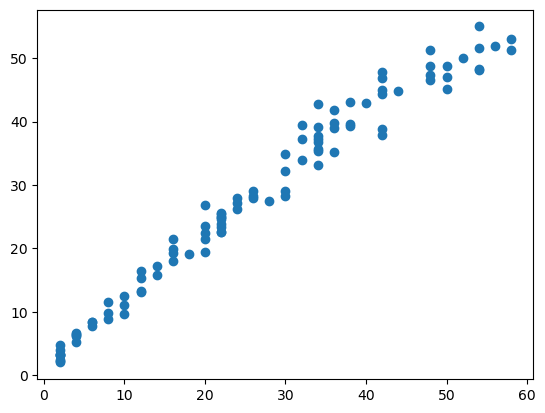

In [37]:
test_preds = final_model.predict(x_test_data)
test_rmse = root_mean_squared_error(y_test_data, test_preds)
test_r2 = r2_score(y_test_data, test_preds)

print(f"Test Set RMSE: {test_rmse:.4f}")
print(f"Test Set R²:   {test_r2:.4f}")
plt.scatter(y_test_data,test_preds)

<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
/var/folders/yz/rw67lhy57ydft79yc0xyyc140000gn/T/ipykernel_83737/2384444986.py:33: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted Concentration ($\hat{y}$)', fontsize=11)


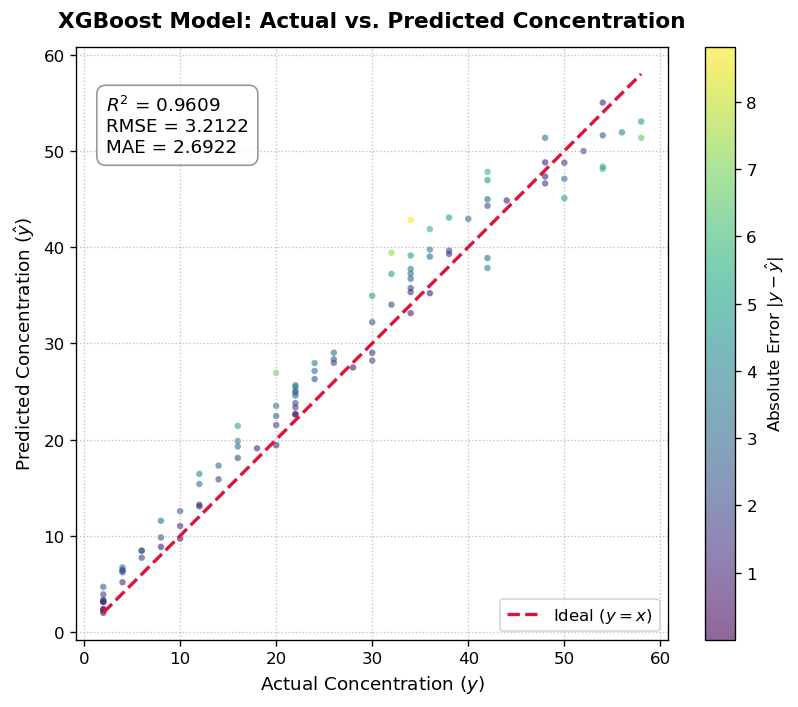

In [ ]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

r2 = r2_score(y_test_data, test_preds)
rmse = root_mean_squared_error(y_test_data, test_preds)
mae = mean_absolute_error(y_test_data, test_preds)
errors = np.abs(y_test_data - test_preds)

plt.figure(figsize=(7, 6), dpi=120)

scatter = plt.scatter(
    y_test_data, test_preds, 
    c=errors, cmap='viridis', 
    alpha=0.6, s=15, edgecolors='none'
)
plt.colorbar(scatter, label='Absolute Error $|y - \\hat{y}|$')

min_val = min(y_test_data.min(), test_preds.min())
max_val = max(y_test_data.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Ideal ($y=x$)')

textstr = f'$R^2$ = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}'
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
plt.gca().text(0.05, 0.92, textstr, transform=plt.gca().transAxes, fontsize=11, verticalalignment='top', bbox=props)

# 5. Styling
plt.title('XGBoost Model: Actual vs. Predicted Concentration', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual Concentration ($y$)', fontsize=11)
plt.ylabel('Predicted Concentration ($\hat{y}$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


In [ ]:
import optuna.visualization as vis

fig = vis.plot_param_importances(study)
fig.show()

fig_history = vis.plot_optimization_history(study)
fig_history.show()

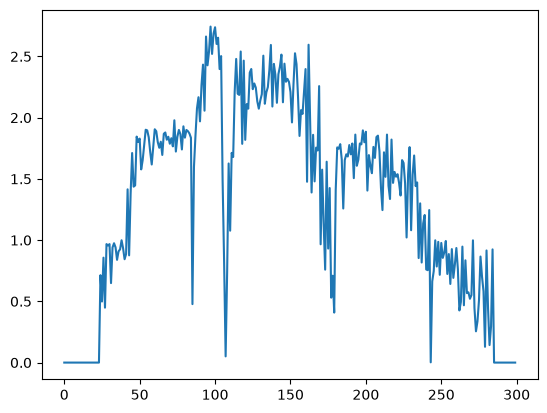

In [8]:
plt.plot(np.load("/home/shardul/transmission_results/consolidated_data/size_7/size_7_8.npy")[0])